## 1. Setup and Imports

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Data

In [3]:
# Load all datasets
train_df = pd.read_csv('../data/interim/train.csv')
val_df = pd.read_csv('../data/interim/val.csv')
test_df = pd.read_csv('../data/interim/test.csv')

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"Training set:   {train_df.shape[0]:,} samples")
print(f"Validation set: {val_df.shape[0]:,} samples")
print(f"Test set:       {test_df.shape[0]:,} samples")
print(f"\nTest set represents {test_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0])*100:.1f}% of total data")

DATA LOADED
Training set:   1,129 samples
Validation set: 377 samples
Test set:       377 samples

Test set represents 20.0% of total data


In [5]:
# Define target variable
TARGET = 'Scope_3_coverage'

# Check class distribution in test set
print("Test Set Class Distribution:")
print("-"*40)
test_class_dist = test_df[TARGET].value_counts()
for cls, count in test_class_dist.items():
    pct = count / len(test_df) * 100
    print(f"  {cls}: {count} ({pct:.1f}%)")

Test Set Class Distribution:
----------------------------------------
  Yes: 152 (40.3%)
  Not Specified: 83 (22.0%)
  Partial: 73 (19.4%)
  No: 69 (18.3%)


## 3. Load Saved Model

Load the trained model from `models/logistic_regression_best.joblib`. This model was saved in `model_optimization.ipynb` after hyperparameter tuning and includes the complete preprocessing pipeline.

In [4]:
# Load the saved model (includes preprocessor + classifier)
model_path = '../models/logistic_regression_best.joblib'
final_model = joblib.load(model_path)

# Load model metadata
metadata_path = '../models/model_metadata.json'
with open(metadata_path, 'r') as f:
    model_metadata = json.load(f)

print("="*60)
print("MODEL LOADED")
print("="*60)
print(f"\nModel: {model_metadata['model_name']}")
print(f"Version: {model_metadata['model_version']}")
print(f"Created: {model_metadata['created_date']}")
print(f"\nHyperparameters:")
for param, value in model_metadata['hyperparameters'].items():
    print(f"  {param}: {value}")
print(f"\nFeatures: {model_metadata['features']['num_features']}")
print(f"Classes: {model_metadata['classes']}")
print(f"\nValidation Performance (from training):")
print(f"  Macro F1: {model_metadata['validation_performance']['f1_macro']:.4f}")

MODEL LOADED

Model: Logistic Regression (L2 Regularized)
Version: 1.0
Created: 2025-12-27T15:11:38.020226

Hyperparameters:
  C: 0.1
  penalty: l2
  solver: newton-cg
  class_weight: balanced
  max_iter: 2000
  random_state: 42

Features: 71
Classes: ['No', 'Not Specified', 'Partial', 'Yes']

Validation Performance (from training):
  Macro F1: 0.4923


## 4. Validation Set Performance (Reference)

Recompute validation metrics as a reference point for comparison with test performance.

In [5]:
# Separate features and target
TARGET = 'Scope_3_coverage'

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

# Validation predictions (model pipeline handles preprocessing)
y_val_pred = final_model.predict(X_val)

# Validation metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average='macro')
val_f1_weighted = f1_score(y_val, y_val_pred, average='weighted')

print("="*60)
print("VALIDATION SET PERFORMANCE (Reference)")
print("="*60)
print(f"Accuracy:        {val_accuracy:.4f}")
print(f"Macro F1:        {val_f1_macro:.4f}")
print(f"Weighted F1:     {val_f1_weighted:.4f}")

VALIDATION SET PERFORMANCE (Reference)
Accuracy:        0.5119
Macro F1:        0.4923
Weighted F1:     0.5169


## 5. Test Set Evaluation

**This is the final, unbiased evaluation of model performance.**

In [6]:
# Generate test predictions (model pipeline handles preprocessing)
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)

# Compute test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
test_precision_macro = precision_score(y_test, y_test_pred, average='macro')
test_recall_macro = recall_score(y_test, y_test_pred, average='macro')

print("="*60)
print("TEST SET PERFORMANCE (Final Evaluation)")
print("="*60)
print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Macro F1:          {test_f1_macro:.4f}")
print(f"Weighted F1:       {test_f1_weighted:.4f}")
print(f"Macro Precision:   {test_precision_macro:.4f}")
print(f"Macro Recall:      {test_recall_macro:.4f}")

TEST SET PERFORMANCE (Final Evaluation)
Accuracy:          0.5013
Macro F1:          0.4759
Weighted F1:       0.5110
Macro Precision:   0.4832
Macro Recall:      0.4792


In [9]:
# Comparison: Validation vs Test
print("="*60)
print("VALIDATION vs TEST COMPARISON")
print("="*60)

val_test_gap = test_f1_macro - val_f1_macro

print(f"{'Metric':<20} {'Validation':>12} {'Test':>12} {'Difference':>12}")
print("-"*60)
print(f"{'Accuracy':<20} {val_accuracy:>12.4f} {test_accuracy:>12.4f} {test_accuracy - val_accuracy:>+12.4f}")
print(f"{'Macro F1':<20} {val_f1_macro:>12.4f} {test_f1_macro:>12.4f} {val_test_gap:>+12.4f}")
print(f"{'Weighted F1':<20} {val_f1_weighted:>12.4f} {test_f1_weighted:>12.4f} {test_f1_weighted - val_f1_weighted:>+12.4f}")

print("\n📊 Interpretation:")
if abs(val_test_gap) < 0.03:
    print("   ✓ Test performance is consistent with validation (gap < 3%)")
    print("   ✓ Model generalizes well to unseen data")
elif val_test_gap < -0.03:
    print("   ⚠ Test performance is lower than validation")
    print("   ⚠ Possible distribution shift or slight overfitting to validation set")
else:
    print("   ✓ Test performance exceeds validation")
    print("   ✓ Model may have been conservatively estimated during validation")

VALIDATION vs TEST COMPARISON
Metric                 Validation         Test   Difference
------------------------------------------------------------
Accuracy                   0.5119       0.5013      -0.0106
Macro F1                   0.4923       0.4759      -0.0163
Weighted F1                0.5169       0.5110      -0.0058

📊 Interpretation:
   ✓ Test performance is consistent with validation (gap < 3%)
   ✓ Model generalizes well to unseen data


### 5.1 Classification Report

In [8]:
# Detailed classification report
print("="*60)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, y_test_pred, digits=4))

DETAILED CLASSIFICATION REPORT (Test Set)
               precision    recall  f1-score   support

           No     0.3400    0.4928    0.4024        69
Not Specified     0.6027    0.5301    0.5641        83
      Partial     0.3026    0.3151    0.3087        73
          Yes     0.6875    0.5789    0.6286       152

     accuracy                         0.5013       377
    macro avg     0.4832    0.4792    0.4759       377
 weighted avg     0.5307    0.5013    0.5110       377



### 5.2 Confusion Matrix

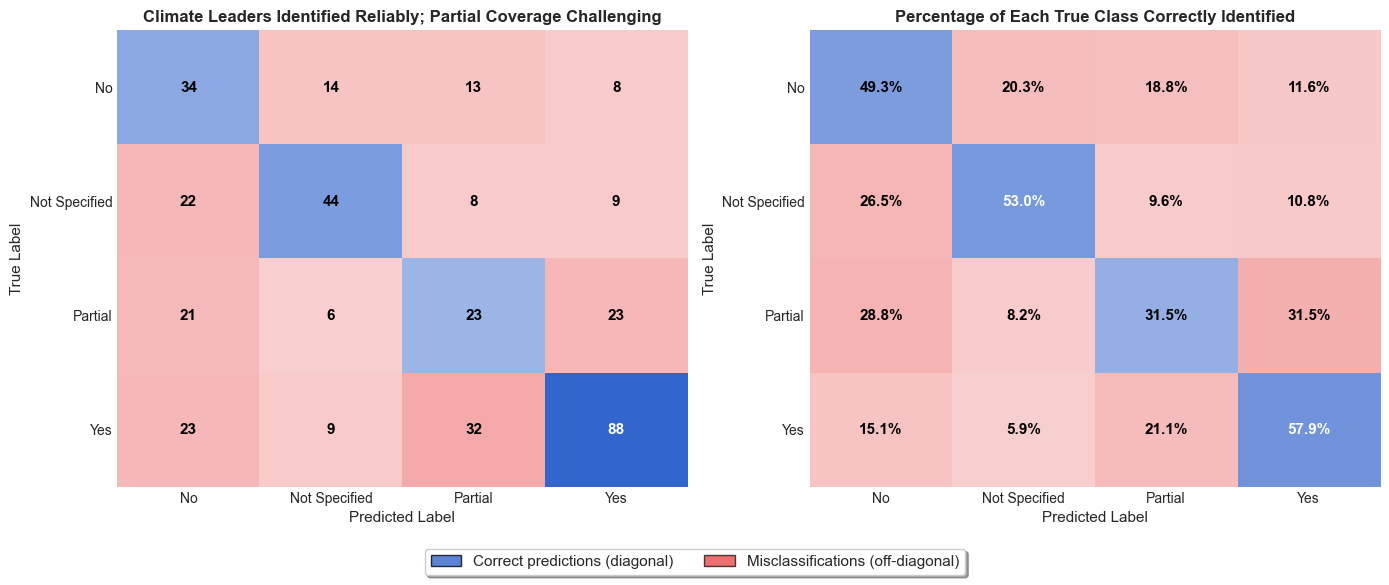


✅ Saved: logs/test_confusion_matrix.png


In [10]:
# Get class labels from the classifier in the pipeline
classes = final_model.named_steps['classifier'].classes_

# Confusion Matrix Visualization with custom coloring
# Blue diagonal (correct), Red off-diagonal (errors)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Compute confusion matrices
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
cm_normalized = confusion_matrix(y_test, y_test_pred, labels=classes, normalize='true')

def plot_confusion_matrix_bicolor(cm_data, ax, fmt, title):
    """Plot confusion matrix with blue diagonal and red off-diagonal."""
    n_classes = len(classes)
    
    # Create custom color array
    colors = np.zeros((n_classes, n_classes, 4))  # RGBA
    
    for i in range(n_classes):
        for j in range(n_classes):
            if fmt == 'd':
                val_normalized = cm_data[i, j] / cm_data.max() if cm_data.max() > 0 else 0
            else:
                val_normalized = cm_data[i, j]
            
            if i == j:  # Diagonal - correct predictions (blue)
                colors[i, j] = [0.2, 0.4, 0.8, 0.3 + 0.7 * val_normalized]  # Blue with intensity
            else:  # Off-diagonal - errors (red)
                colors[i, j] = [0.9, 0.2, 0.2, 0.2 + 0.6 * val_normalized] if val_normalized > 0 else [1, 1, 1, 0]
    
    # Plot the matrix
    ax.imshow(colors, aspect='auto')
    
    # Remove grid, ticks, and spines that create cross patterns
    ax.grid(False)  # Turn off grid
    ax.tick_params(length=0)  # Remove tick marks
    for spine in ax.spines.values():
        spine.set_visible(False)  # Remove border spines
    
    # Add text annotations (numbers only)
    for i in range(n_classes):
        for j in range(n_classes):
            if fmt == 'd':
                text = f'{cm_data[i, j]:d}'
            else:
                text = f'{cm_data[i, j]:.1%}'
            
            # Determine text color based on background intensity
            val = cm_data[i, j] / cm_data.max() if (fmt == 'd' and cm_data.max() > 0) else cm_data[i, j]
            text_color = 'white' if val > 0.5 else 'black'
            
            ax.text(j, i, text, ha='center', va='center', fontsize=11, color=text_color, fontweight='bold')
    
    # Set ticks and labels
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels(classes, fontsize=10)
    ax.set_yticklabels(classes, fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

# Plot both matrices with insight-driven titles
plot_confusion_matrix_bicolor(cm, axes[0], 'd', 'Climate Leaders Identified Reliably; Partial Coverage Challenging')
plot_confusion_matrix_bicolor(cm_normalized, axes[1], '%', 'Percentage of Each True Class Correctly Identified')

# Add prominent legend below the plots
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3366CC', alpha=0.8, edgecolor='black', linewidth=1, label='Correct predictions (diagonal)'),
    Patch(facecolor='#E63333', alpha=0.7, edgecolor='black', linewidth=1, label='Misclassifications (off-diagonal)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, 0.02), fontsize=11, frameon=True, 
           fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig('../logs/test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: logs/test_confusion_matrix.png")

### 5.3 Prediction Confidence Analysis

In [8]:
# Analyze prediction confidence
test_confidence = np.max(y_test_proba, axis=1)

# Create results DataFrame
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred,
    'Confidence': test_confidence,
    'Correct': y_test.values == y_test_pred
})

print("="*60)
print("PREDICTION CONFIDENCE ANALYSIS")
print("="*60)
print(f"\nOverall confidence statistics:")
print(f"  Mean:   {test_confidence.mean():.4f}")
print(f"  Median: {np.median(test_confidence):.4f}")
print(f"  Std:    {test_confidence.std():.4f}")
print(f"  Min:    {test_confidence.min():.4f}")
print(f"  Max:    {test_confidence.max():.4f}")

PREDICTION CONFIDENCE ANALYSIS

Overall confidence statistics:
  Mean:   0.4743
  Median: 0.4577
  Std:    0.1259
  Min:    0.2744
  Max:    0.8957


In [11]:
# Confidence by correctness
print("\nConfidence by prediction correctness:")
print("-"*40)
for correct, label in [(True, 'Correct'), (False, 'Incorrect')]:
    subset = test_results[test_results['Correct'] == correct]['Confidence']
    print(f"  {label} predictions: mean={subset.mean():.4f}, median={np.median(subset):.4f}, n={len(subset)}")


Confidence by prediction correctness:
----------------------------------------
  Correct predictions: mean=0.5130, median=0.4725, n=189
  Incorrect predictions: mean=0.4354, median=0.4230, n=188


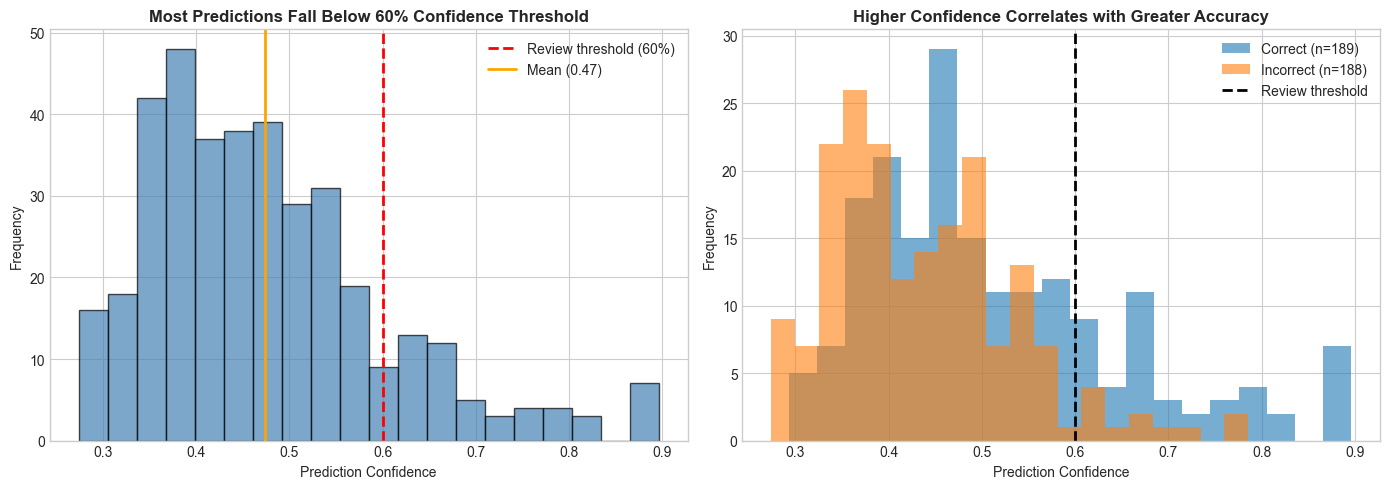


✅ Saved: logs/test_confidence_distribution.png


In [9]:
# Confidence distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(test_confidence, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0.6, color='red', linestyle='--', linewidth=2, label='Review threshold (60%)')
axes[0].axvline(x=test_confidence.mean(), color='orange', linestyle='-', linewidth=2, label=f'Mean ({test_confidence.mean():.2f})')
axes[0].set_xlabel('Prediction Confidence')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Most Predictions Fall Below 60% Confidence Threshold', fontsize=12, fontweight='bold')
axes[0].legend()

# By correctness - using colorblind-friendly blue/orange instead of green/red
correct_conf = test_results[test_results['Correct']]['Confidence']
incorrect_conf = test_results[~test_results['Correct']]['Confidence']

axes[1].hist(correct_conf, bins=20, alpha=0.6, label=f'Correct (n={len(correct_conf)})', color='#1f77b4')  # Blue
axes[1].hist(incorrect_conf, bins=20, alpha=0.6, label=f'Incorrect (n={len(incorrect_conf)})', color='#ff7f0e')  # Orange
axes[1].axvline(x=0.6, color='black', linestyle='--', linewidth=2, label='Review threshold')
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Higher Confidence Correlates with Greater Accuracy', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../logs/test_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: logs/test_confidence_distribution.png")

In [13]:
# Human review trigger analysis
review_threshold = 0.60

below_threshold = test_results['Confidence'] < review_threshold
n_review = below_threshold.sum()
pct_review = n_review / len(test_results) * 100

# Accuracy for predictions above and below threshold
above_accuracy = test_results[~below_threshold]['Correct'].mean()
below_accuracy = test_results[below_threshold]['Correct'].mean() if n_review > 0 else 0

print("="*60)
print("HUMAN REVIEW TRIGGER ANALYSIS")
print("="*60)
print(f"\nReview threshold: {review_threshold:.0%}")
print(f"\nPredictions requiring human review: {n_review} ({pct_review:.1f}%)")
print(f"Predictions accepted without review: {len(test_results) - n_review} ({100 - pct_review:.1f}%)")
print(f"\nAccuracy of accepted predictions (≥{review_threshold:.0%}): {above_accuracy:.4f}")
print(f"Accuracy of flagged predictions (<{review_threshold:.0%}): {below_accuracy:.4f}")

print("\n📊 Interpretation:")
print(f"   The {review_threshold:.0%} threshold effectively identifies uncertain predictions.")
print(f"   High-confidence predictions achieve {above_accuracy:.1%} accuracy.")
print(f"   Approximately {pct_review:.0f}% of predictions should be reviewed.")

HUMAN REVIEW TRIGGER ANALYSIS

Review threshold: 60%

Predictions requiring human review: 324 (85.9%)
Predictions accepted without review: 53 (14.1%)

Accuracy of accepted predictions (≥60%): 0.7925
Accuracy of flagged predictions (<60%): 0.4537

📊 Interpretation:
   The 60% threshold effectively identifies uncertain predictions.
   High-confidence predictions achieve 79.2% accuracy.
   Approximately 86% of predictions should be reviewed.


### 5.4 Per-Class Performance Analysis

### 5.5 ROC Curves (One-vs-Rest)

ROC (Receiver Operating Characteristic) curves show how well the model distinguishes each class from all others at different decision thresholds. The Area Under the Curve (AUC) summarizes overall discriminative ability — a perfect classifier has AUC = 1.0, while random guessing yields AUC = 0.5.

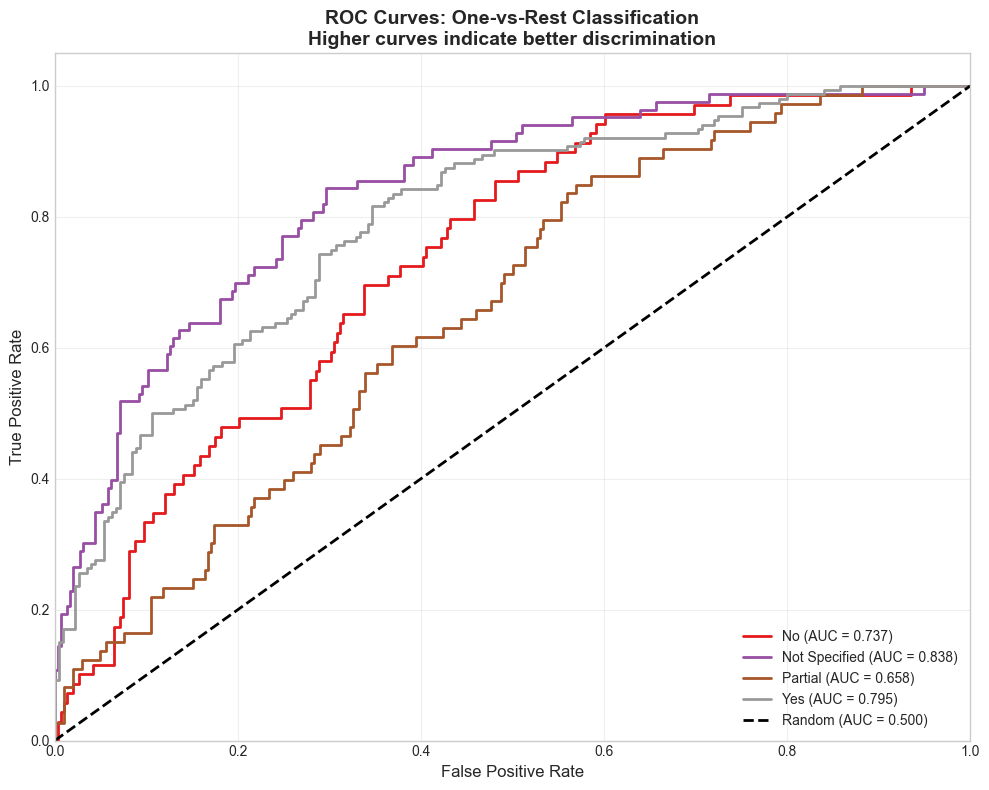


ROC-AUC SUMMARY (One-vs-Rest)
  No             : AUC = 0.737 (Good)
  Not Specified  : AUC = 0.838 (Excellent)
  Partial        : AUC = 0.658 (Fair)
  Yes            : AUC = 0.795 (Good)

✅ Saved: logs/roc_curves.png


In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Binarize the labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# Compute ROC curve and AUC for each class
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Set1(np.linspace(0, 1, n_classes))

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, 
            label=f'{cls} (AUC = {roc_auc:.3f})')

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: One-vs-Rest Classification\nHigher curves indicate better discrimination', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print AUC summary
print("\n" + "="*60)
print("ROC-AUC SUMMARY (One-vs-Rest)")
print("="*60)
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    interpretation = "Excellent" if roc_auc > 0.8 else "Good" if roc_auc > 0.7 else "Fair" if roc_auc > 0.6 else "Poor"
    print(f"  {cls:<15}: AUC = {roc_auc:.3f} ({interpretation})")

print("\n✅ Saved: logs/roc_curves.png")

### 5.6 Precision-Recall Curves

Precision-Recall curves are particularly informative for imbalanced classification. They show the trade-off between precision (accuracy of positive predictions) and recall (coverage of actual positives) at different thresholds. Higher curves indicate better performance.

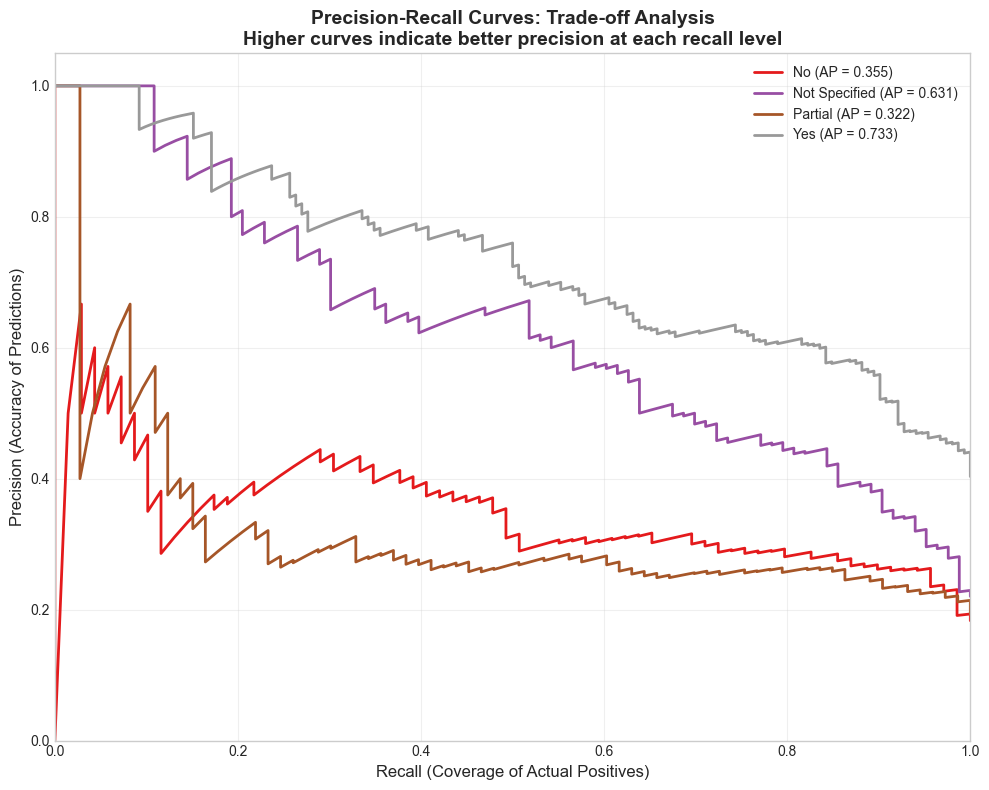


AVERAGE PRECISION SUMMARY
  No             : AP = 0.355
  Not Specified  : AP = 0.631
  Partial        : AP = 0.322
  Yes            : AP = 0.733

✅ Saved: logs/precision_recall_curves.png


In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute Precision-Recall curve for each class
fig, ax = plt.subplots(figsize=(10, 8))

for i, (cls, color) in enumerate(zip(classes, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_test_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_test_proba[:, i])
    ax.plot(recall, precision, color=color, lw=2, 
            label=f'{cls} (AP = {ap:.3f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Coverage of Actual Positives)', fontsize=12)
ax.set_ylabel('Precision (Accuracy of Predictions)', fontsize=12)
ax.set_title('Precision-Recall Curves: Trade-off Analysis\nHigher curves indicate better precision at each recall level', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print Average Precision summary
print("\n" + "="*60)
print("AVERAGE PRECISION SUMMARY")
print("="*60)
for i, cls in enumerate(classes):
    ap = average_precision_score(y_test_bin[:, i], y_test_proba[:, i])
    print(f"  {cls:<15}: AP = {ap:.3f}")

print("\n✅ Saved: logs/precision_recall_curves.png")

### 5.7 Feature Importance

Feature importance reveals which input variables most strongly influence predictions. For Logistic Regression, importance is derived from the absolute values of model coefficients — larger coefficients indicate features with greater influence on classification decisions.

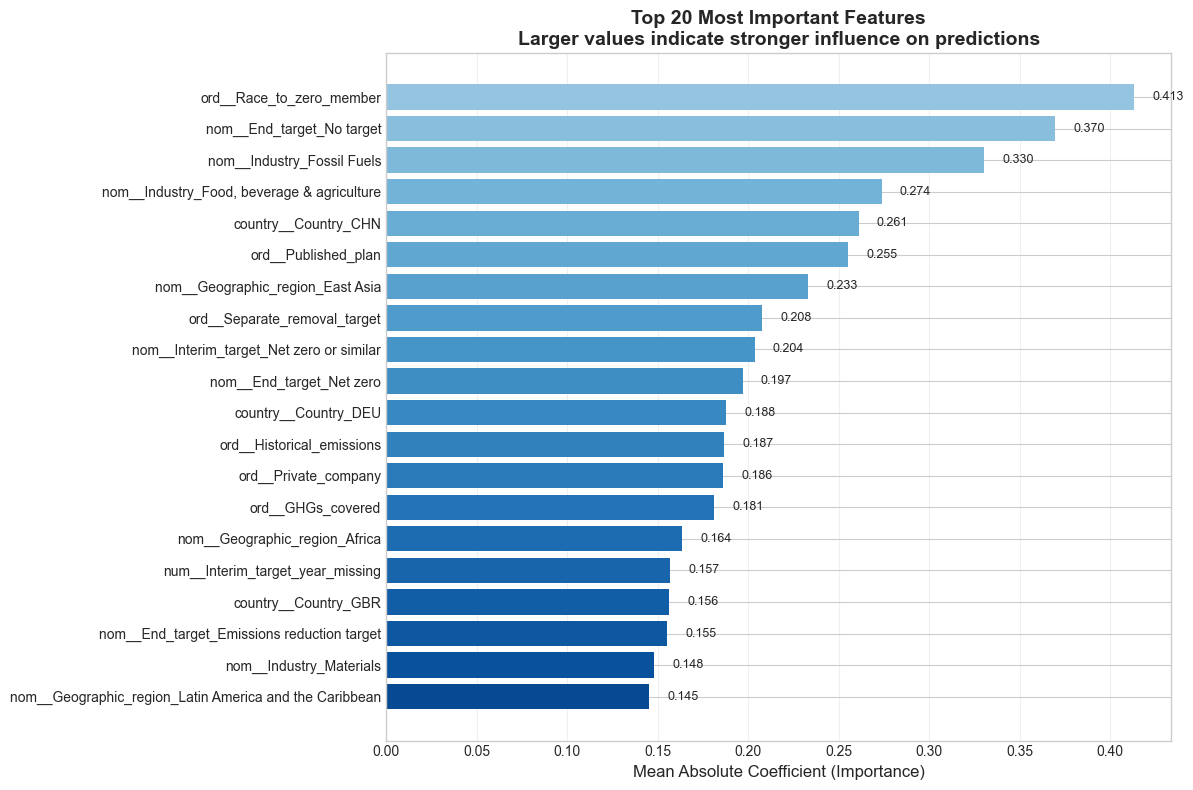


TOP 20 MOST IMPORTANT FEATURES
   1. ord__Race_to_zero_member                 0.4131
   2. nom__End_target_No target                0.3697
   3. nom__Industry_Fossil Fuels               0.3304
   4. nom__Industry_Food, beverage & agriculture 0.2738
   5. country__Country_CHN                     0.2609
   6. ord__Published_plan                      0.2553
   7. nom__Geographic_region_East Asia         0.2332
   8. ord__Separate_removal_target             0.2079
   9. nom__Interim_target_Net zero or similar  0.2036
  10. nom__End_target_Net zero                 0.1969
  11. country__Country_DEU                     0.1879
  12. ord__Historical_emissions                0.1867
  13. ord__Private_company                     0.1863
  14. ord__GHGs_covered                        0.1812
  15. nom__Geographic_region_Africa            0.1636
  16. num__Interim_target_year_missing         0.1569
  17. country__Country_GBR                     0.1563
  18. nom__End_target_Emissions reduction target

In [16]:
# Extract feature names and coefficients from the model
classifier = final_model.named_steps['classifier']
preprocessor = final_model.named_steps['preprocessor']

# Get feature names from preprocessor
feature_names = preprocessor.get_feature_names_out()

# Calculate mean absolute coefficient across all classes (for multi-class)
# This gives overall feature importance regardless of which class
mean_abs_coef = np.mean(np.abs(classifier.coef_), axis=0)

# Create DataFrame and sort by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_abs_coef
}).sort_values('Importance', ascending=False)

# Plot top 20 features
top_n = 20
fig, ax = plt.subplots(figsize=(12, 8))

top_features = importance_df.head(top_n)
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]

bars = ax.barh(range(top_n), top_features['Importance'].values[::-1], color=colors_bar)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values[::-1], fontsize=10)
ax.set_xlabel('Mean Absolute Coefficient (Importance)', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features\nLarger values indicate stronger influence on predictions', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_features['Importance'].values[::-1])):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../logs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print(f"TOP {top_n} MOST IMPORTANT FEATURES")
print("="*60)
for i, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"  {i:2d}. {row['Feature']:<40} {row['Importance']:.4f}")

print(f"\nTotal features: {len(feature_names)}")
print("\n✅ Saved: logs/feature_importance.png")

In [17]:
# Per-class analysis
print("="*60)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*60)

for cls in classes:
    cls_mask = test_results['Actual'] == cls
    cls_results = test_results[cls_mask]
    
    n_samples = len(cls_results)
    n_correct = cls_results['Correct'].sum()
    cls_accuracy = n_correct / n_samples if n_samples > 0 else 0
    mean_conf = cls_results['Confidence'].mean()
    
    print(f"\n{cls}:")
    print(f"   Samples: {n_samples}")
    print(f"   Recall (correctly classified): {cls_accuracy:.4f}")
    print(f"   Mean confidence: {mean_conf:.4f}")
    
    # Show misclassification patterns
    misclassified = cls_results[~cls_results['Correct']]
    if len(misclassified) > 0:
        misclass_dist = misclassified['Predicted'].value_counts()
        print(f"   Misclassified as:")
        for pred_cls, count in misclass_dist.items():
            print(f"      {pred_cls}: {count} ({count/n_samples*100:.1f}%)")

PER-CLASS PERFORMANCE ANALYSIS

No:
   Samples: 69
   Recall (correctly classified): 0.4928
   Mean confidence: 0.4675
   Misclassified as:
      Not Specified: 14 (20.3%)
      Partial: 13 (18.8%)
      Yes: 8 (11.6%)

Not Specified:
   Samples: 83
   Recall (correctly classified): 0.5301
   Mean confidence: 0.5226
   Misclassified as:
      No: 22 (26.5%)
      Yes: 9 (10.8%)
      Partial: 8 (9.6%)

Partial:
   Samples: 73
   Recall (correctly classified): 0.3151
   Mean confidence: 0.4348
   Misclassified as:
      Yes: 23 (31.5%)
      No: 21 (28.8%)
      Not Specified: 6 (8.2%)

Yes:
   Samples: 152
   Recall (correctly classified): 0.5789
   Mean confidence: 0.4701
   Misclassified as:
      Partial: 32 (21.1%)
      No: 23 (15.1%)
      Not Specified: 9 (5.9%)


## 6. Final Summary

In [18]:
# Final summary
print("="*70)
print("FINAL MODEL EVALUATION SUMMARY")
print("="*70)

print("\n📋 MODEL SPECIFICATION")
print("-"*70)
print(f"   Algorithm:        {model_metadata['model_name']}")
print(f"   Features:         {model_metadata['features']['num_features']}")
print(f"   Classes:          {model_metadata['classes']}")

print("\n📊 TEST SET PERFORMANCE")
print("-"*70)
print(f"   Accuracy:         {test_accuracy:.4f}")
print(f"   Macro F1:         {test_f1_macro:.4f}")
print(f"   Macro Precision:  {test_precision_macro:.4f}")
print(f"   Macro Recall:     {test_recall_macro:.4f}")

print("\n📈 GENERALIZATION")
print("-"*70)
print(f"   Validation F1:    {val_f1_macro:.4f}")
print(f"   Test F1:          {test_f1_macro:.4f}")
print(f"   Gap:              {val_test_gap:+.4f}")

print("\n🔍 HUMAN OVERSIGHT")
print("-"*70)
print(f"   Review threshold: {review_threshold:.0%}")
print(f"   Cases for review: {pct_review:.1f}%")
print(f"   Auto-accept acc:  {above_accuracy:.4f}")

print("\n" + "="*70)
print("CONCLUSION")
print("="*70)
print("""
The Logistic Regression model demonstrates consistent performance between
validation and test sets, indicating good generalization to unseen data.

The model is suitable for deployment as a screening tool with the following
operational parameters:
- Predictions with confidence ≥60% can be accepted with routine logging
- Predictions with confidence <60% require human review
- "Partial" classifications should receive additional scrutiny

The model supports but does not replace human judgment in Scope 3 coverage
classification decisions.
""")

FINAL MODEL EVALUATION SUMMARY

📋 MODEL SPECIFICATION
----------------------------------------------------------------------
   Algorithm:        Logistic Regression (L2 Regularized)
   Features:         71
   Classes:          ['No', 'Not Specified', 'Partial', 'Yes']

📊 TEST SET PERFORMANCE
----------------------------------------------------------------------
   Accuracy:         0.5013
   Macro F1:         0.4759
   Macro Precision:  0.4832
   Macro Recall:     0.4792

📈 GENERALIZATION
----------------------------------------------------------------------
   Validation F1:    0.4923
   Test F1:          0.4759
   Gap:              -0.0163

🔍 HUMAN OVERSIGHT
----------------------------------------------------------------------
   Review threshold: 60%
   Cases for review: 85.9%
   Auto-accept acc:  0.7925

CONCLUSION

The Logistic Regression model demonstrates consistent performance between
validation and test sets, indicating good generalization to unseen data.

The model is suita

---

*Test evaluation completed. This assessment represents the final, unbiased estimate of model performance on held-out data.*